# Additional reviewer-requested diagnostics

This notebook covers three small diagnostic requests from the reviewer that don't require large refit sweeps or the full METEOR pipeline:

1. **5-year smoothing window sensitivity** (Reviewer comment 2). Compare seasonal-cycle fits with 3-, 5-, and 10-year rolling means applied to $T_{\text{glob}}$.
2. **VARX innovation Gaussianity** (Reviewer comment 6). Empirical check of the Gaussian assumption on the VARX residuals via QQ plots and normality tests.
3. **Gamma MLE fallback frequency** (Reviewer comment 7). Report how often the vectorized gamma MLE hits its degenerate-case fallback across the NorESM2-MM precipitation grid.

The fourth reviewer request (formal chi-squared uniformity p-values on the rank histograms, comment 5) is handled directly in the two paper notebooks that generate the rank-histogram figures themselves (`METEOR_Interface_Paper_plots.ipynb` for the in-sample Figure 4, and `Multi_Model_Out_of_Sample_Validation.ipynb` for the out-of-sample Figure 8). Doing it there keeps the p-values consistent with the rank arrays actually plotted.

Outputs written to `../paper/paper_figures/`:
- `suppfig_smoothing_sensitivity.{pdf,png}`
- `suppfig_innovation_gaussianity.{pdf,png}`
- `suppfig_gamma_fallback.{pdf,png}`

Runtime: ~15 minutes end-to-end on a laptop. Pickle caching in `./diagnostics_cache/` makes re-runs fast.

## 1. Setup

In [1]:
import os
import sys
import pickle
from pathlib import Path
import warnings

REPO_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')

from meteor.noise_generator import MeteorNoiseGenerator
from meteor.precipitation_transform import _vectorized_gamma_mle

CACHE = REPO_ROOT / 'cache' / 'cmip6'
NOISE_MODELS = REPO_ROOT / 'cache' / 'noise_models'
FIGURE_DIR = os.environ.get('METEOR_PAPER_FIGURES', '../paper/paper_figures')
os.makedirs(FIGURE_DIR, exist_ok=True)

CACHE_LOCAL = Path('./diagnostics_cache')
CACHE_LOCAL.mkdir(exist_ok=True)

MODEL = 'NorESM2-MM'
SCENARIO = 'ssp245'

def cached(name):
    def deco(fn):
        def wrap(*args, **kwargs):
            path = CACHE_LOCAL / f'{name}.pkl'
            if path.exists():
                print(f'loading cached {name}')
                with open(path, 'rb') as f:
                    return pickle.load(f)
            out = fn(*args, **kwargs)
            with open(path, 'wb') as f:
                pickle.dump(out, f)
            print(f'wrote cache: {path}')
            return out
        return wrap
    return deco

def load_composite(variable):
    hist = xr.open_dataset(CACHE / f'{MODEL}_historical_{variable}_monthly.nc')
    ssp  = xr.open_dataset(CACHE / f'{MODEL}_{SCENARIO}_{variable}_monthly.nc')
    start = int(hist['month'].values[-1]) + 1
    ssp = ssp.assign_coords(month=np.arange(start, start + ssp.sizes['month']))
    return xr.concat([hist, ssp], dim='month')

def picontrol_baseline(variable):
    ds = xr.open_dataset(CACHE / f'{MODEL}_piControl_{variable}_yearly.nc')
    return float(ds[variable].mean().values)

def save_and_show(fig, name):
    '''Save fig as PDF + PNG, display inline, then close.'''
    pdf = os.path.join(FIGURE_DIR, f'{name}.pdf')
    png = os.path.join(FIGURE_DIR, f'{name}.png')
    fig.savefig(pdf, bbox_inches='tight')
    fig.savefig(png, bbox_inches='tight', dpi=150)
    print(f'saved: {pdf}')
    print(f'saved: {png}')
    display(fig)
    plt.close(fig)

print(f'FIGURE_DIR: {FIGURE_DIR}')
print(f'CACHE: {CACHE}')

FIGURE_DIR: ../paper/paper_figures
CACHE: /Users/bensan/GitHub/METEOR/cache/cmip6


## 2. 5-year smoothing window sensitivity

Refit the noise model on NorESM2-MM SSP2-4.5 with the $T_{\text{glob}}$ smoothing window set to 3, 5, and 10 years respectively. Compare the seasonal-model $R^2$, the leading harmonic regression coefficients, and the total variance explained (seasonal + PCA). A robust choice should show a broad plateau across windows in this range.

In [2]:
def area_weighted_gmt(ds, variable):
    da = ds[variable].mean(dim='ens')
    w = np.cos(np.deg2rad(da['lat']))
    return (da.weighted(w).mean(dim=['lat', 'lon']).values)

def compute_t_glob(ds, variable, window_years, baseline):
    raw = area_weighted_gmt(ds, variable) - baseline
    win_mo = window_years * 12
    da = xr.DataArray(raw, dims=('month',))
    smoothed = (da.rolling(month=win_mo, center=True, min_periods=1)
                  .mean()
                  .interpolate_na('month', method='nearest', fill_value='extrapolate')
                  .values)
    return smoothed

@cached('smoothing_sensitivity')
def run_smoothing_sensitivity():
    data = load_composite('tas')
    baseline = picontrol_baseline('tas')
    results = {}
    for w in (3, 5, 10):
        print(f'  window = {w} yr')
        t_glob = compute_t_glob(data, 'tas', w, baseline)
        gen = MeteorNoiseGenerator(n_modes=40, lag_order=2, use_exog='none')
        gen.fit(data, 'tas', custom_global_temp=t_glob,
                picontrol_baseline=baseline)
        results[w] = dict(
            seasonal_r2=float(gen.diagnostics['seasonal_r2']),
            total_var=float(gen.diagnostics['total_variance_explained']),
            seasonal_coef=gen.seasonal_model.coef_.copy(),
            t_glob=t_glob.copy(),
        )
    return results

smoothing_results = run_smoothing_sensitivity()
print('\nSummary:')
for w, r in smoothing_results.items():
    print(f'  {w:2d}-yr window: seasonal R^2 = {r["seasonal_r2"]:.4f}  total var explained = {r["total_var"]:.4f}')

loading cached smoothing_sensitivity

Summary:
   3-yr window: seasonal R^2 = 0.8797  total var explained = 0.9679
   5-yr window: seasonal R^2 = 0.8773  total var explained = 0.9674
  10-yr window: seasonal R^2 = 0.8742  total var explained = 0.9668


saved: ../paper/paper_figures/suppfig_smoothing_sensitivity.pdf
saved: ../paper/paper_figures/suppfig_smoothing_sensitivity.png


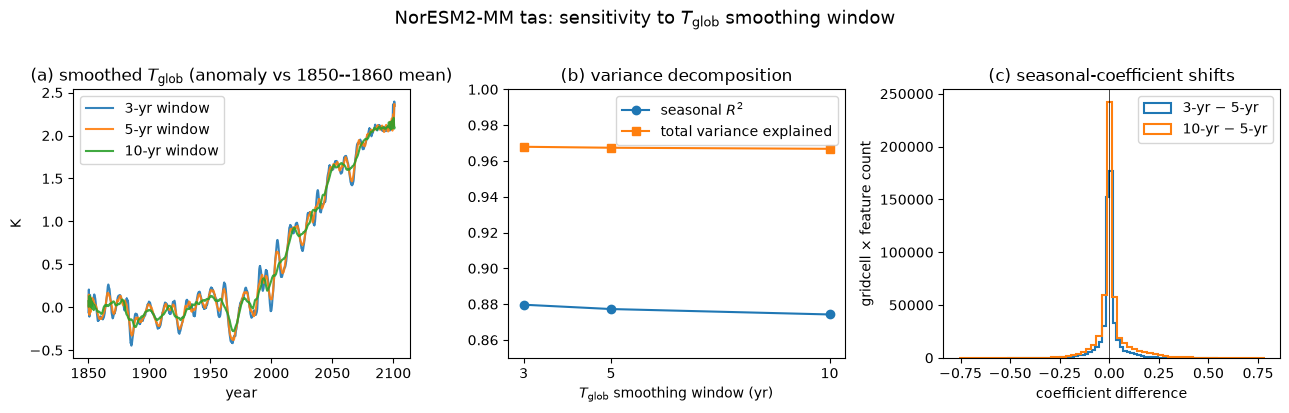

In [3]:
def render_smoothing(results, name):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    # (a) smoothed t_glob curves, anomaly vs first-decade mean of each curve
    for w, r in results.items():
        yr = np.arange(len(r['t_glob'])) / 12 + 1850
        curve = r['t_glob']
        ref = curve[:120].mean()  # first 10 yr as reference
        axes[0].plot(yr, curve - ref, label=f'{w}-yr window', alpha=0.9)
    axes[0].set_title('(a) smoothed $T_{\\mathrm{glob}}$ (anomaly vs 1850--1860 mean)')
    axes[0].set_xlabel('year')
    axes[0].set_ylabel('K')
    axes[0].legend()

    # (b) seasonal R^2 vs window
    windows = sorted(results.keys())
    r2s = [results[w]['seasonal_r2'] for w in windows]
    totals = [results[w]['total_var'] for w in windows]
    axes[1].plot(windows, r2s, 'o-', label='seasonal $R^2$')
    axes[1].plot(windows, totals, 's-', label='total variance explained')
    axes[1].set_xticks(windows)
    axes[1].set_xlabel('$T_{\\mathrm{glob}}$ smoothing window (yr)')
    axes[1].set_title('(b) variance decomposition')
    axes[1].set_ylim(0.85, 1.0)
    axes[1].legend()

    # (c) seasonal coefficient distribution differences (5-yr as reference)
    ref = results[5]['seasonal_coef']
    for w in windows:
        if w == 5:
            continue
        diff = (results[w]['seasonal_coef'] - ref).ravel()
        axes[2].hist(diff, bins=60, histtype='step', label=f'{w}-yr $-$ 5-yr', linewidth=1.5)
    axes[2].axvline(0, color='k', lw=0.5)
    axes[2].set_title('(c) seasonal-coefficient shifts')
    axes[2].set_xlabel('coefficient difference')
    axes[2].set_ylabel('gridcell $\\times$ feature count')
    axes[2].legend()

    fig.suptitle(f'{MODEL} tas: sensitivity to $T_{{\\mathrm{{glob}}}}$ smoothing window',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    save_and_show(fig, name)

render_smoothing(smoothing_results, 'suppfig_smoothing_sensitivity')

## 4. VARX innovation Gaussianity

Check the empirical distribution of the VARX residuals $\varepsilon(t)$ against the Gaussian assumption. For each of the top PCs we run a Shapiro-Wilk normality test and produce a QQ plot. Rejection of the null (p < 0.05) means the residuals deviate significantly from Gaussian; large samples make even mild deviations detectable, so the QQ shape carries most of the interpretive weight.

In [6]:
@cached('innovation_gaussianity')
def run_innovation_gaussianity():
    out = {}
    for variable in ('tas', 'pr'):
        gen = load_noise(variable)
        resid = gen.varx_results.resid  # (n_obs, n_modes)
        n_test = min(10, resid.shape[1])
        rows = []
        for k in range(n_test):
            r = resid[:, k]
            # Anderson-Darling has finite critical values for large n; Shapiro-Wilk
            # in scipy caps at n=5000 for exact p, so we use Anderson-Darling here.
            ad = stats.anderson(r, dist='norm')
            skew = float(stats.skew(r))
            kurt = float(stats.kurtosis(r))  # excess kurtosis
            rows.append(dict(pc=k, ad_stat=float(ad.statistic),
                             skew=skew, excess_kurt=kurt,
                             std=float(r.std())))
        out[variable] = dict(resid=resid, rows=rows)
        print(f'--- {variable} innovations ---')
        print(f'  n_obs = {resid.shape[0]}, n_modes = {resid.shape[1]}')
        for r in rows[:5]:
            print(f'  PC {r["pc"]+1}: A-D={r["ad_stat"]:.3f}  skew={r["skew"]:+.3f}  ex.kurt={r["excess_kurt"]:+.3f}')
    return out

gauss_results = run_innovation_gaussianity()

loading cached innovation_gaussianity


saved: ../paper/paper_figures/suppfig_innovation_gaussianity.pdf
saved: ../paper/paper_figures/suppfig_innovation_gaussianity.png


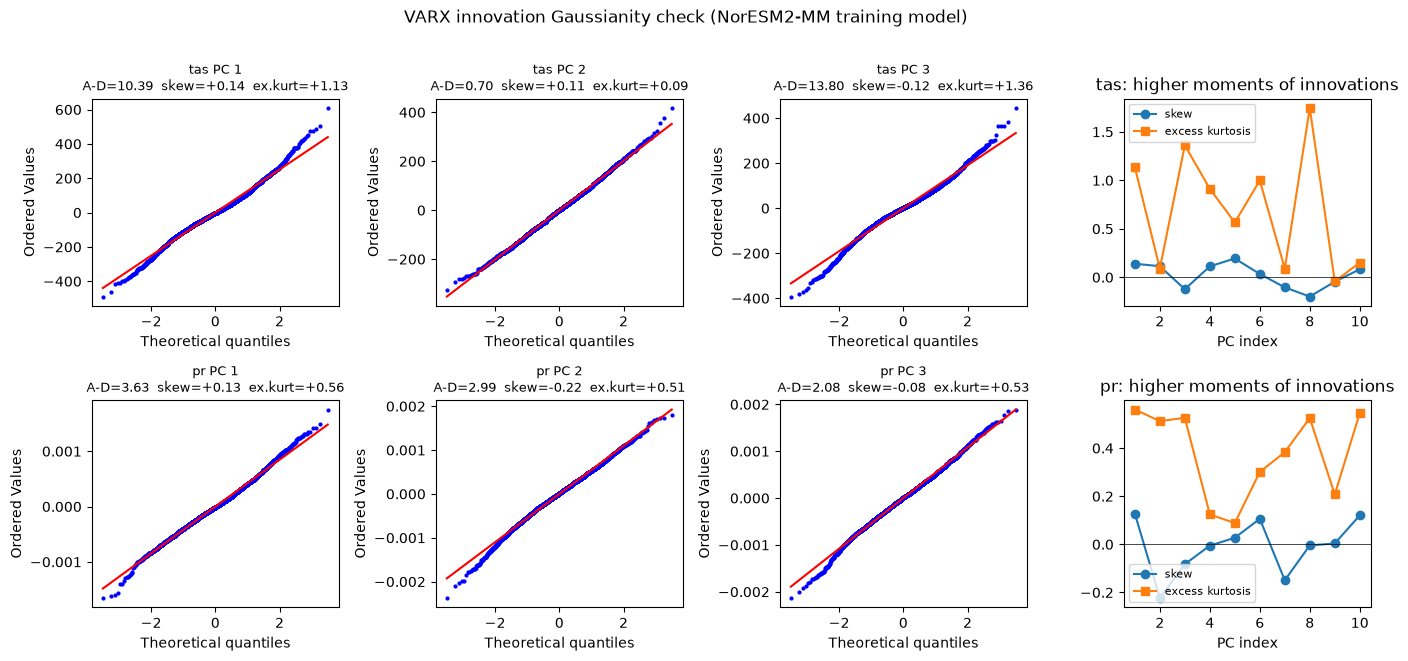

In [7]:
def render_gaussianity(results, name):
    fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
    for i, variable in enumerate(('tas', 'pr')):
        resid = results[variable]['resid']
        rows = results[variable]['rows']
        for k in range(3):
            ax = axes[i, k]
            stats.probplot(resid[:, k], dist='norm', plot=ax)
            r = rows[k]
            ax.set_title(f'{variable} PC {k+1}\nA-D={r["ad_stat"]:.2f}  '
                         f'skew={r["skew"]:+.2f}  ex.kurt={r["excess_kurt"]:+.2f}',
                         fontsize=9)
            ax.get_lines()[0].set_markersize(2)
        ax = axes[i, 3]
        pcs = [r['pc']+1 for r in rows]
        ax.plot(pcs, [r['skew'] for r in rows], 'o-', label='skew')
        ax.plot(pcs, [r['excess_kurt'] for r in rows], 's-', label='excess kurtosis')
        ax.axhline(0, color='k', lw=0.5)
        ax.set_xlabel('PC index')
        ax.set_title(f'{variable}: higher moments of innovations')
        ax.legend(fontsize=8)
    fig.suptitle('VARX innovation Gaussianity check (NorESM2-MM training model)',
                 fontsize=12, y=1.01)
    fig.tight_layout()
    save_and_show(fig, name)

render_gaussianity(gauss_results, 'suppfig_innovation_gaussianity')

## 5. Gamma MLE fallback frequency

The precipitation transform uses a vectorized gamma MLE (`_vectorized_gamma_mle`) at each gridpoint. Gridpoints with fewer than 2 positive samples or with degenerate log-mean/mean-log relationships fall back to a canonical `(shape=1, scale=mean)` --- functionally the method-of-moments fallback the paper describes. Here we count how often the fallback fires across the NorESM2-MM SSP2-4.5 grid and map the spatial distribution to check whether it coincides with regions of poor precipitation emulation.

In [8]:
def instrumented_gamma_fit(data):
    '''Return (shape, scale, fittable_mask). Mirrors _vectorized_gamma_mle's
    internal fittable calculation to expose which gridpoints hit the fallback.
    '''
    x = np.asarray(data, dtype=np.float64)
    valid = (x > 0) & np.isfinite(x)
    n_valid = valid.sum(axis=0)
    x_masked = np.where(valid, x, 0.0)
    logx_masked = np.where(valid, np.log(np.maximum(x, np.finfo(float).tiny)), 0.0)
    with np.errstate(invalid='ignore', divide='ignore'):
        mean_x = x_masked.sum(axis=0) / n_valid
        mean_logx = logx_masked.sum(axis=0) / n_valid
        s = np.log(mean_x) - mean_logx
    fittable = (n_valid >= 2) & np.isfinite(s) & (s > 0)
    shape, scale = _vectorized_gamma_mle(x)
    return shape, scale, fittable, n_valid, s

@cached('gamma_fallback')
def run_gamma_fallback():
    ssp = xr.open_dataset(CACHE / f'{MODEL}_{SCENARIO}_pr_monthly.nc')
    pr = ssp['pr'].mean(dim='ens')  # (month, lat, lon)
    n_time, n_lat, n_lon = pr.shape
    reshaped = pr.values.reshape(n_time, n_lat * n_lon)
    shape, scale, fittable, n_valid, s = instrumented_gamma_fit(reshaped)
    fallback_map = (~fittable).reshape(n_lat, n_lon)
    n_valid_map = n_valid.reshape(n_lat, n_lon)
    frac = float(fallback_map.mean())
    print(f'gridpoints: {n_lat * n_lon}')
    print(f'fallback fraction: {frac:.4%}')
    print(f'  (n_valid < 2): {(n_valid < 2).sum()} gridpoints')
    print(f'  (s <= 0 or not finite, but n_valid >= 2): {(fittable == False).sum() - (n_valid < 2).sum()}')
    return dict(
        shape_map=shape.reshape(n_lat, n_lon),
        scale_map=scale.reshape(n_lat, n_lon),
        fallback_map=fallback_map,
        n_valid_map=n_valid_map,
        fraction=frac,
        lat=pr['lat'].values,
        lon=pr['lon'].values,
    )

gamma_results = run_gamma_fallback()

loading cached gamma_fallback


saved: ../paper/paper_figures/suppfig_gamma_fallback.pdf
saved: ../paper/paper_figures/suppfig_gamma_fallback.png


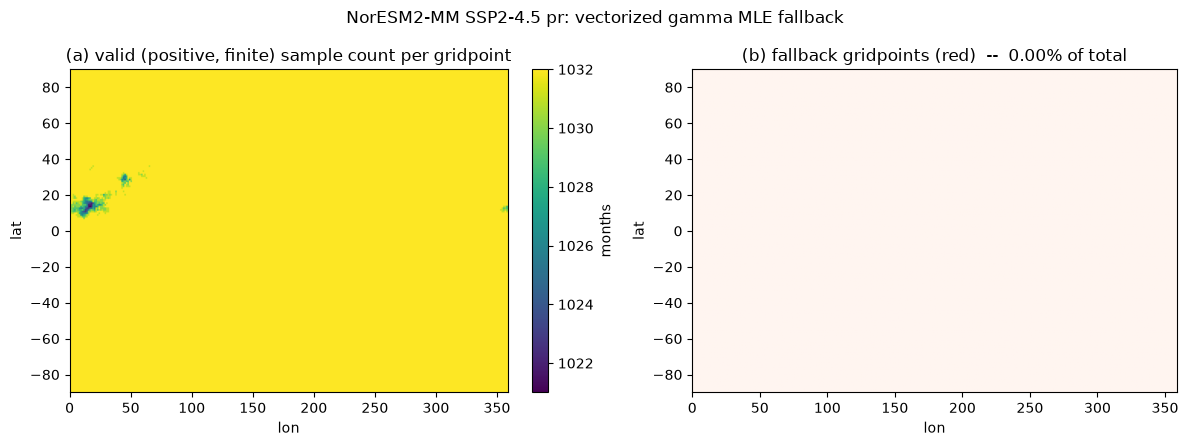

In [9]:
def render_gamma(results, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    im = ax.imshow(results['n_valid_map'], origin='lower', cmap='viridis',
                   extent=[results['lon'][0], results['lon'][-1],
                           results['lat'][0], results['lat'][-1]],
                   aspect='auto')
    ax.set_title('(a) valid (positive, finite) sample count per gridpoint')
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')
    fig.colorbar(im, ax=ax, fraction=0.046, label='months')

    ax = axes[1]
    ax.imshow(results['fallback_map'].astype(float), origin='lower', cmap='Reds',
              extent=[results['lon'][0], results['lon'][-1],
                      results['lat'][0], results['lat'][-1]],
              aspect='auto', vmin=0, vmax=1)
    ax.set_title(f'(b) fallback gridpoints (red)  --  {results["fraction"]:.2%} of total')
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

    fig.suptitle(f'{MODEL} SSP2-4.5 pr: vectorized gamma MLE fallback', fontsize=12)
    fig.tight_layout()
    save_and_show(fig, name)

render_gamma(gamma_results, 'suppfig_gamma_fallback')

## 6. Numerical summary

Compact output for copying into the response letter.

In [ ]:
print('=== 5-yr smoothing sensitivity ===')
for w in sorted(smoothing_results):
    r = smoothing_results[w]
    print(f'  {w:2d}-yr window: seasonal R^2 = {r["seasonal_r2"]:.4f}  '
          f'total variance explained = {r["total_var"]:.4f}')

print('\n=== VARX innovation moments (top 5 PCs) ===')
for var, entry in gauss_results.items():
    print(f'  {var}:')
    for r in entry['rows'][:5]:
        print(f'    PC {r["pc"]+1}: A-D={r["ad_stat"]:.3f}  '
              f'skew={r["skew"]:+.3f}  ex.kurt={r["excess_kurt"]:+.3f}')

print(f'\n=== Gamma MLE fallback (NorESM2-MM ssp245 pr) ===')
print(f'  fraction of gridpoints hitting fallback: {gamma_results["fraction"]:.4%}')
print(f'  (of {gamma_results["fallback_map"].size} total gridpoints)')